<div style="display:flex; align-items:flex-start; justify-content:space-between; gap:24px; border-bottom:3px solid #8f001a; padding-bottom:16px;">
  <div>
    <h1 style="margin-bottom:0.35em;">Exercise 6: Review Loop for Log-Pearson Type III Flood Frequency</h1>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Faculty of Engineering, University of Ottawa</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Provided By:</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;">Professor Hossein Bonakdari</p>
    <p style="font-size:1.05em; margin:0.2em 0;">PhD Candidate Mohammad Hashtari</p>
  </div>
  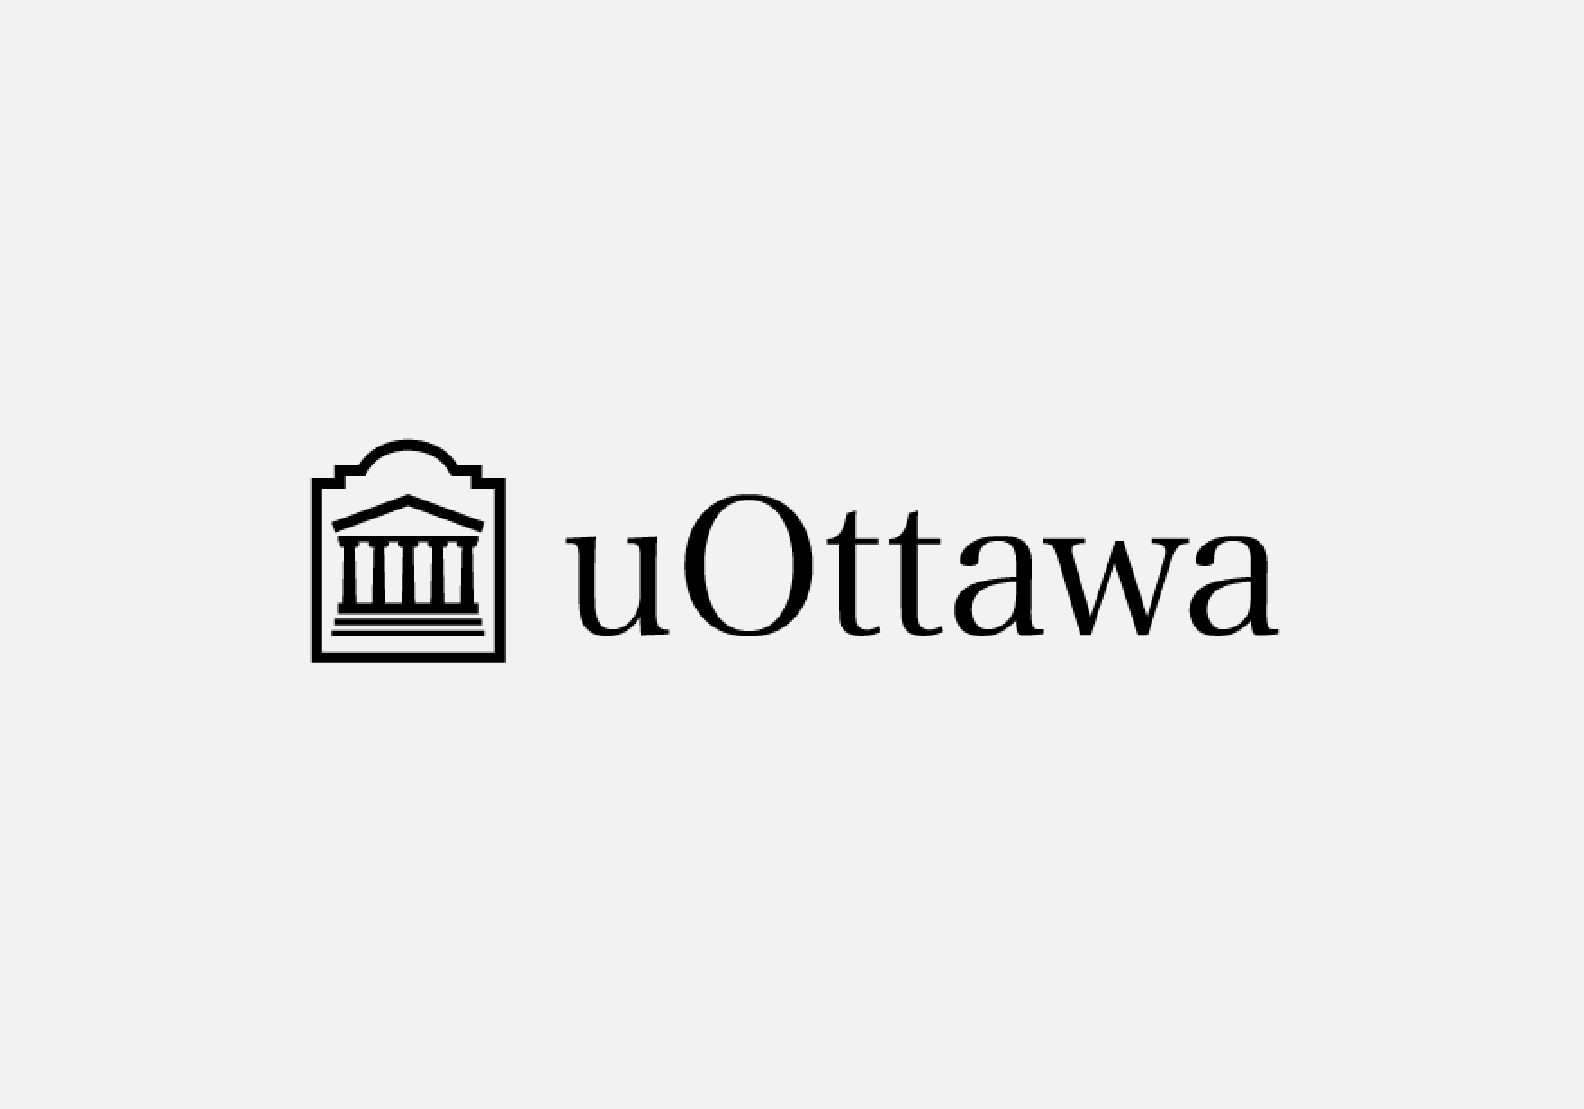
</div>

This notebook teaches how an independent review loop improves AI-assisted scientific code. The hydrology example is a simplified Log-Pearson Type III flood-frequency function for annual maximum streamflow.

In [ ]:
# Browser package setup for JupyterLite. Safe to run in local Jupyter too.
import sys

if sys.platform == "emscripten":
    import piplite
    await piplite.install(["numpy", "pandas", "matplotlib", "scipy"])


## 1. Source Basis

The flood-frequency method is based on U.S. flood-frequency guidance:

- England, J. F., Jr., Cohn, T. A., Faber, B. A., Stedinger, J. R., Thomas, W. O., Jr., Veilleux, A. G., Kiang, J. E., and Mason, R. R., Jr. (2018). *Guidelines for determining flood flow frequency: Bulletin 17C*. U.S. Geological Survey Techniques and Methods 4-B5. https://doi.org/10.3133/tm4B5
- Interagency Advisory Committee on Water Data. (1982). *Guidelines for determining flood flow frequency: Bulletin 17B*. https://doi.org/10.3133/70275162

Scientific note: this notebook demonstrates the core LP3 idea by fitting a Pearson Type III distribution to log10 annual maxima. It does not implement the full Bulletin 17C Expected Moments Algorithm, historical information, perception thresholds, or regional skew procedures.

## 2. Learning Goal

A coder-reviewer loop separates two roles:

1. The coder writes or revises the implementation.
2. The reviewer inspects the current code without relying on the coder's reasoning.
3. The coder receives concrete issues and revises.
4. The loop stops only when tests and review criteria are satisfied.

Hydrology target: implement `fit_lp3(flows)` so it returns Q2, Q10, Q50, and Q100 estimates from annual maximum flows.

## 3. Libraries

The notebook uses `numpy`, `pandas`, `matplotlib`, and `scipy.stats.pearson3`.

In [ ]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from scipy.stats import pearson3

RETURN_PERIODS = [2, 10, 50, 100]

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 4. Annual Maximum Streamflow Record

The example uses a 20-year annual maximum series in cubic feet per second. LP3 fitting assumes the input series already contains one annual maximum per year.

In [ ]:
annual_maxima_cfs = np.array([
    800.0, 1100.0, 950.0, 1300.0, 870.0, 1450.0, 1020.0, 1200.0, 760.0, 1600.0,
    900.0, 1050.0, 1380.0, 980.0, 1250.0, 830.0, 1500.0, 1100.0, 940.0, 1700.0,
])

annual_record = pd.DataFrame({
    "water_year_index": np.arange(1, len(annual_maxima_cfs) + 1),
    "annual_peak_cfs": annual_maxima_cfs,
})

annual_record.head()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(annual_record["water_year_index"], annual_record["annual_peak_cfs"], marker="o", color="#0b7285")
ax.set_title("Annual Maximum Streamflow Series")
ax.set_xlabel("Water year index")
ax.set_ylabel("Annual peak discharge (cfs)")
plt.show()

## 5. Review Loop Concept

The reviewer should inspect the code as if it came from another person. It should check method correctness, edge cases, input validation, and hydrological limitations.

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.set_axis_off()

steps = [
    ('Task', 'LP3 flood-frequency function'),
    ('Coder', 'Writes current draft'),
    ('Reviewer', 'Checks code only'),
    ('Revise', 'Fix blocking issues'),
    ('Verify', 'Run tests and sanity checks'),
]

x = 0.12
width = 0.76
height = 0.105
if len(steps) == 1:
    y_positions = [0.50]
else:
    y_positions = [0.78 - i * (0.66 / (len(steps) - 1)) for i in range(len(steps))]

for i, ((step_title, subtitle), y) in enumerate(zip(steps, y_positions)):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#264653",
        facecolor="#edf6f9",
        transform=ax.transAxes,
    )
    ax.add_patch(box)
    ax.text(x + 0.035, y + height * 0.64, step_title, ha="left", va="center", fontsize=11, weight="bold", transform=ax.transAxes)
    ax.text(x + 0.035, y + height * 0.30, subtitle, ha="left", va="center", fontsize=9, transform=ax.transAxes)
    if i < len(steps) - 1:
        next_y = y_positions[i + 1]
        ax.annotate(
            "", xy=(0.50, next_y + height + 0.015), xytext=(0.50, y - 0.015),
            arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#264653"},
            xycoords=ax.transAxes,
        )

ax.set_title('Independent Review Loop', pad=12)
plt.show()

## 6. Before Prompt

A weak prompt asks for code without a separate review step:

```text
Write a Python function that fits a Log-Pearson Type III distribution and returns Q2, Q10, Q50, and Q100.
```

The result may look reasonable while missing input validation, log-domain handling, or return-period probability conventions.

## 7. After Prompt

A stronger prompt separates implementation and review:

```text
Use a coder-reviewer loop for fit_lp3(flows).
Coder: implement LP3 in log10 space using Pearson Type III and return Q2, Q10, Q50, and Q100.
Reviewer: inspect only the current code and task. Check LP3 probability convention, non-positive flows, records shorter than 10 years, monotonic return-period estimates, and scale preservation.
Feed reviewer issues back to the coder until the implementation passes tests or reaches three rounds.
```

The review criteria are explicit, hydrology-aware, and testable.

## 8. Reviewer Checklist

The reviewer should catch issues that are easy to miss in a single-shot implementation.

In [ ]:
review_checks = pd.DataFrame({
    "check": [
        "minimum record length",
        "positive flows before log transform",
        "log10-space fitting",
        "annual exceedance probability convention",
        "monotonic return-period estimates",
        "unit scale preservation",
        "clear method limitation",
    ],
    "why_it_matters": [
        "short records cannot support stable flood-frequency estimates",
        "zero or negative values are invalid in log space",
        "LP3 flood frequency is fitted to logarithms of annual peaks",
        "Q100 uses non-exceedance probability 0.99 for annual maxima",
        "larger return periods should produce larger flood estimates",
        "multiplying all flows should multiply estimates by the same factor",
        "this simplified fit is not full Bulletin 17C",
    ],
})

review_checks

## 9. Reviewed Implementation

The implementation below applies the review checklist. It raises clear errors for records shorter than 10 observations and for non-positive flows, then fits a Pearson Type III distribution in log10 space.

In [ ]:
def fit_lp3(flows):
    """Fit simplified LP3 flood-frequency estimates for annual maximum flows."""
    q = np.asarray(flows, dtype=float)

    if q.ndim != 1:
        raise ValueError("flows must be a one-dimensional sequence")
    if len(q) < 10:
        raise ValueError("at least 10 annual maxima are required")
    if np.any(~np.isfinite(q)):
        raise ValueError("flows must be finite")
    if np.any(q <= 0):
        raise ValueError("LP3 fitting requires positive annual maximum flows")

    log_q = np.log10(q)
    skew, loc, scale = pearson3.fit(log_q)

    estimates = {}
    for return_period in RETURN_PERIODS:
        nonexceedance_probability = 1.0 - 1.0 / return_period
        log_estimate = pearson3.ppf(nonexceedance_probability, skew, loc=loc, scale=scale)
        estimates[f"return_{return_period}"] = float(10 ** log_estimate)

    return estimates


lp3_estimates = fit_lp3(annual_maxima_cfs)
lp3_estimates

## 10. Verification Tests

The tests combine code properties and hydrological expectations.

In [ ]:
result = fit_lp3(annual_maxima_cfs)

assert set(result.keys()) == {"return_2", "return_10", "return_50", "return_100"}
assert result["return_2"] < result["return_10"] < result["return_50"] < result["return_100"]
assert all(value > 0 for value in result.values())
assert result["return_100"] > np.max(annual_maxima_cfs)

geo_mean = math.exp(np.mean(np.log(annual_maxima_cfs)))
assert abs(result["return_2"] - geo_mean) / geo_mean < 0.30

scaled = fit_lp3(annual_maxima_cfs * 10.0)
for key in result:
    assert abs((scaled[key] / result[key]) - 10.0) / 10.0 < 0.05

try:
    fit_lp3([100.0, 200.0, 300.0])
    raise AssertionError("short records should fail")
except ValueError:
    pass

try:
    fit_lp3([0.0, *annual_maxima_cfs])
    raise AssertionError("non-positive flows should fail")
except ValueError:
    pass

print("All LP3 checks passed.")

## 11. Flood-Frequency Estimates

The estimates are dimensionally consistent with the input discharge unit. Because the example is short, Q50 and Q100 should be treated as illustrative extrapolations.

In [ ]:
estimate_table = pd.DataFrame({
    "return_period_years": RETURN_PERIODS,
    "estimated_discharge_cfs": [lp3_estimates[f"return_{period}"] for period in RETURN_PERIODS],
})

estimate_table

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(estimate_table["return_period_years"], estimate_table["estimated_discharge_cfs"], marker="o", color="#d9480f", label="LP3 estimate")
ax.axhline(np.max(annual_maxima_cfs), color="#0b7285", linestyle="--", label="Observed maximum")
ax.set_xscale("log")
ax.set_title("Simplified LP3 Flood-Frequency Estimates")
ax.set_xlabel("Return period (years, log scale)")
ax.set_ylabel("Discharge (cfs)")
ax.legend()
plt.show()

## 12. Hydrological Interpretation

The review loop matters because LP3 code can fail silently: fitting in raw-flow space, using the wrong probability tail, accepting zero flows before a log transform, or extrapolating from too short a record can produce plausible-looking but scientifically weak flood estimates. The independent reviewer role forces these assumptions to be checked explicitly before the result is trusted.

## 13. Summary

- A coder-reviewer loop separates implementation from independent critique.
- LP3 flood-frequency fitting should use positive annual maxima in log10 space.
- Q2, Q10, Q50, and Q100 use annual non-exceedance probabilities of 0.5, 0.9, 0.98, and 0.99.
- Tests should check monotonicity, scale preservation, short-record handling, and log-domain validity.
- This notebook demonstrates a simplified LP3 workflow, not a complete Bulletin 17C analysis.